In [20]:
import pandas as pd
import re

In [21]:
file_path = "WhatsAppChat-DataScience2025\_chat.txt"

with open(file_path, "r", encoding="utf-8") as f:
    data = f.read()

print(data[:500])

[07.10.25, 1:44:51 PM] Data Science 2025: ‎Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them.
[07.10.25, 1:44:50 PM] ‎You: ‎‎You created this group
[07.10.25, 1:44:51 PM] Vikrant Singh Thakur: ‎Vikrant Singh Thakur was added
[07.10.25, 1:45:09 PM] ‎You: ‎‎You changed the group name to “Data Science 2025”
[07.10.25, 1:45:19 PM] Martin Bratoi: ‎Martin Bratoi joined using a group link.
[07.10.25, 1:45:37 PM] ~ Shruti Bhandari: ‎~ Shruti Bhandar


In [22]:
pattern = r'\[(\d{2}\.\d{2}\.\d{2}),\s(.+?)\]\s([^:]+):\s(.+)'

matches = re.findall(pattern, data)

df = pd.DataFrame(matches, columns=["Date", "Time", "User", "Message"])
df.head()

,Date,Time,User,Message
0,07.10.25,1:44:51 PM,Data Science 2025,‎Messages and calls are end-to-end encrypted. ...
1,07.10.25,1:44:50 PM,‎You,‎‎You created this group
2,07.10.25,1:44:51 PM,Vikrant Singh Thakur,‎Vikrant Singh Thakur was added
3,07.10.25,1:45:09 PM,‎You,‎‎You changed the group name to “Data Science ...
4,07.10.25,1:45:19 PM,Martin Bratoi,‎Martin Bratoi joined using a group link.


In [23]:
print(df.head())

       Date        Time                  User  \
0  07.10.25  1:44:51 PM     Data Science 2025   
1  07.10.25  1:44:50 PM                  ‎You   
2  07.10.25  1:44:51 PM  Vikrant Singh Thakur   
3  07.10.25  1:45:09 PM                  ‎You   
4  07.10.25  1:45:19 PM         Martin Bratoi   

                                             Message  
0  ‎Messages and calls are end-to-end encrypted. ...  
1                           ‎‎You created this group  
2                    ‎Vikrant Singh Thakur was added  
3  ‎‎You changed the group name to “Data Science ...  
4          ‎Martin Bratoi joined using a group link.  


In [24]:
system_msgs = [
    "end-to-end encrypted",
    "created this group",
    "changed the group name",
    "was added",
    "joined using"
]

df = df[~df["Message"].str.contains("|".join(system_msgs), case=False, na=False)]

df["User"] = df["User"].str.replace("~", "").str.strip()
df["Message"] = df["Message"].str.strip()

In [25]:
print(df.Message.head(200))

11     Join my WhatsApp group. https://chat.whatsapp....
12                                     I'm Martin Bratoi
13                       Hi this is Giridhar reddy(Giri)
14                               ‎~ Shruti Bhandari left
16                                        Hi Shruti here
                             ...                        
239                 Is the classroom same as yersterday?
240                                                  105
241          Guys please mark the attendance before 9:45
242                 We have to do the same as yesterday?
243                                                  Yes
Name: Message, Length: 200, dtype: object


In [26]:
df["Message_Length"] = df["Message"].apply(len)
df["Hour"] = df["Time"].str.extract(r'(\d+)')


In [27]:
#most talkitive
talkative = df["User"].value_counts()
print(talkative)

User
Georgios Terzidis       39
Martin Bratoi           36
Haaris K Khalil         34
‪+91 97668 14930‬       23
‪+91 83296 61608‬       17
Vikrant Singh Thakur    14
Sharvari ♡              13
‪+49 1521 3484102‬      12
Yash                     9
‪+49 1522 7021318‬       8
Giridhar Reddy(Giri)     8
‪+91 81307 57466‬        7
‪+92 300 0931321‬        7
‪+91 76762 47132‬        5
‪+49 160 4297925‬        5
‪+91 91 5876 262 1‬      5
‪+91 93216 92088‬        5
Vinay BG                 4
Anish G                  4
‪+91 91 11 9998 66‬      4
‪+91 6361 741 593‬       3
‪+91 75063 23383‬        3
‪+49 15510 860753‬       3
Atharv                   3
Kalhara                  3
Keyur Chaudhari          2
‪+91 6364 347 374‬       2
‪+91 81048 44962‬        2
‪+91 70585 06668‬        2
‪+91 74065 64849‬        2
Kay Müller               2
Janvi                    2
Data Science 2025        2
‪+91 81977 25033‬        2
Kshitija                 1
‪+49 15510 846081‬       1
‪+49 15510 010935‬     

C:\Users\Anish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129393 (\N{YAWNING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


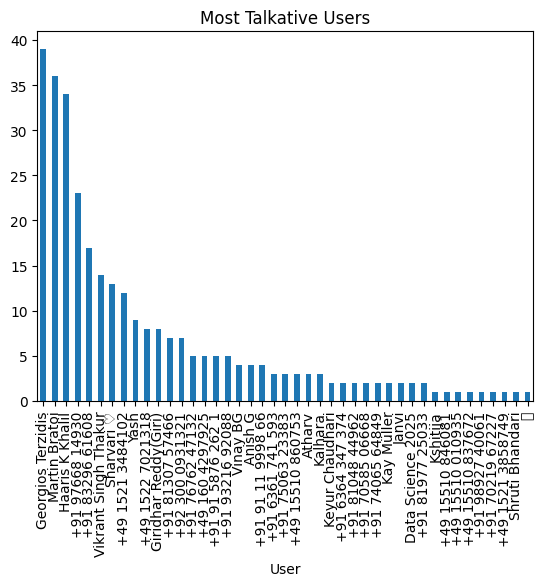

In [28]:
import matplotlib.pyplot as plt

talkative.plot(kind="bar")
plt.title("Most Talkative Users")
plt.show()

In [29]:
#most active
activity_score = df.groupby("User").agg({
    "Message": "count",
    "Message_Length": "mean"
})

activity_score["Score"] = activity_score["Message"] * activity_score["Message_Length"]

activity_score.sort_values("Score", ascending=False)

,Message,Message_Length,Score
User,,,
Georgios Terzidis,39,73.717949,2875.0
Haaris K Khalil,34,76.705882,2608.0
Martin Bratoi,36,49.833333,1794.0
Sharvari ♡,13,53.461538,695.0
Vikrant Singh Thakur,14,32.571429,456.0
‪+91 97668 14930‬,23,19.304348,444.0
‪+49 1521 3484102‬,12,32.083333,385.0
‪+91 83296 61608‬,17,21.235294,361.0
‪+92 300 0931321‬,7,43.714286,306.0


In [30]:
def classify_message(msg):
    msg = msg.lower()

    if any(x in msg for x in ["https://", "http", "www"]):
        return "Link"

    if any(x in msg for x in ["?", "why", "how", "what", "when", "where"]):
        return "Question"

    if any(x in msg for x in ["hi", "hello", "hey", "good morning", "good night"]):
        return "Greeting"

    if any(x in msg for x in ["ok", "okay", "lol", "haha"]):
        return "Casual"

    if any(x in msg for x in ["meeting", "assignment", "project", "exam"]):
        return "Study/Work"

    if any(x in msg for x in ["bro", "dude", "guys"]):
        return "Social"

    return "Other"

In [31]:
df["Category"] = df["Message"].apply(classify_message)

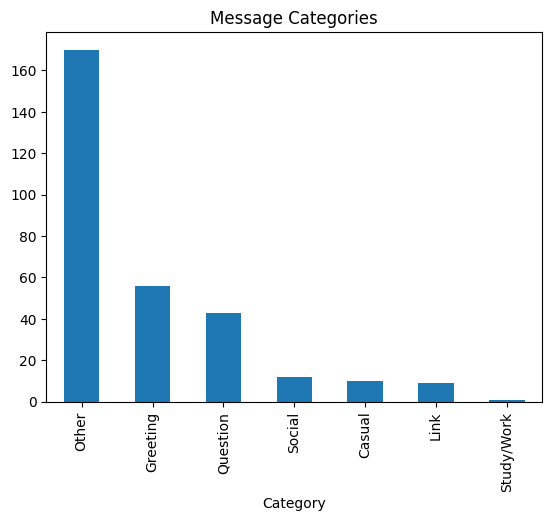

In [32]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")
plt.title("Message Categories")
plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Message"])

In [34]:
df["Category"] = df["Message"].apply(classify_message)
y = df["Category"]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [36]:
df["Predicted_Category"] = model.predict(X)

In [37]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification")

ModuleNotFoundError: No module named 'transformers'

In [ ]:
labels = ["Question", "Greeting", "Work", "Casual", "Link", "Announcement"]

def classify_llm(text):
    result = classifier(text, labels)
    return result["labels"][0]

In [ ]:
df["Category"] = df["Message"].apply(classify_llm)


In [ ]:
df.groupby("Category").size()
df.groupby(["User", "Category"]).size()

User               Category
Anish G            Greeting    2
                   Question    1
                   Work        1
Atharv             Casual      1
                   Link        2
                              ..
‪+91 97668 14930‬  Work        1
‪+91 98927 40061‬  Question    1
‪+92 300 0931321‬  Greeting    1
                   Question    6
🥱                  Casual      1
Length: 109, dtype: int64

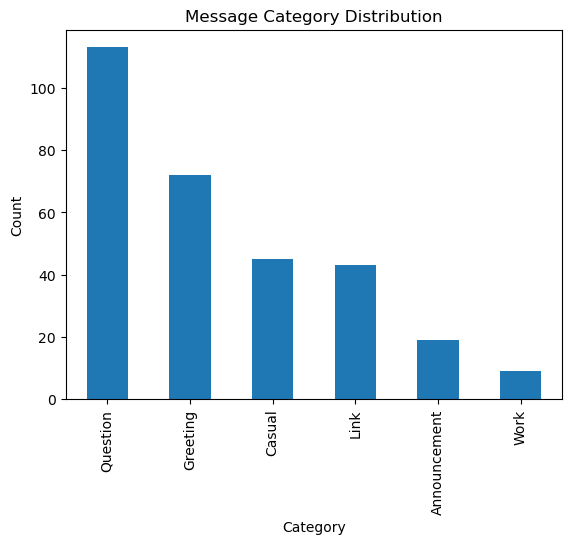

In [ ]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")

plt.title("Message Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

c:\Users\Anish\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129393 (\N{YAWNING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


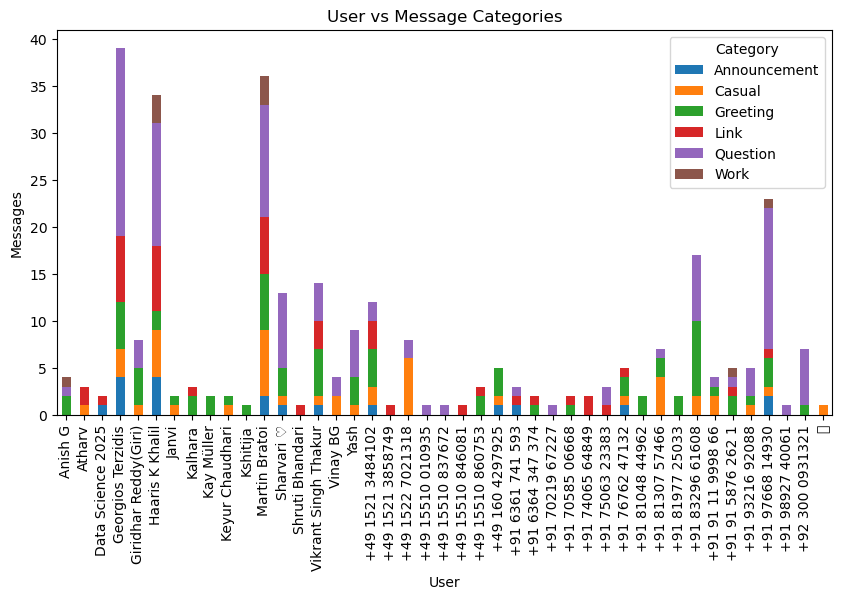

In [ ]:
import pandas as pd

user_cat = pd.crosstab(df["User"], df["Category"])

user_cat.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("User vs Message Categories")
plt.ylabel("Messages")
plt.show()

c:\Users\Anish\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129393 (\N{YAWNING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


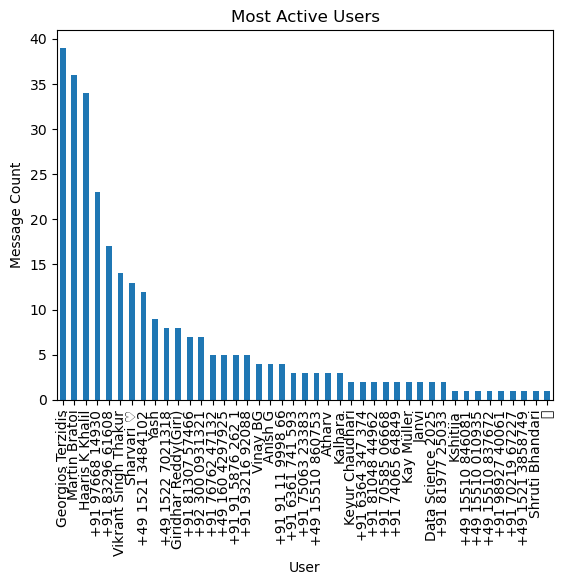

In [ ]:
df["User"].value_counts().plot(kind="bar")

plt.title("Most Active Users")
plt.ylabel("Message Count")
plt.show()

In [ ]:
df["Category"].value_counts()

Category
Other         170
Greeting       56
Question       43
Social         12
Casual         10
Link            9
Study/Work      1
Name: count, dtype: int64

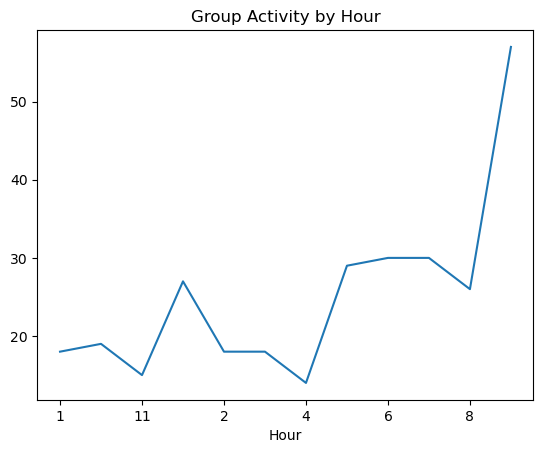

In [ ]:
df["Hour"].value_counts().sort_index().plot(kind="line")
plt.title("Group Activity by Hour")
plt.show()

In [ ]:
df["Date"].value_counts().head(10)

Date
12.10.25    40
25.12.25    23
14.10.25    23
07.10.25    20
01.01.26    17
23.10.25    10
09.10.25     9
27.10.25     8
18.11.25     7
29.10.25     6
Name: count, dtype: int64

In [ ]:
from textblob import TextBlob

df["Sentiment"] = df["Message"].apply(lambda x: TextBlob(x).sentiment.polarity)

df.groupby("User")["Sentiment"].mean().sort_values()

User
‪+92 300 0931321‬      -0.016071
‪+49 15510 837672‬      0.000000
‪+91 98927 40061‬       0.000000
‪+91 93216 92088‬       0.000000
‪+91 91 11 9998 66‬     0.000000
‪+91 81307 57466‬       0.000000
‪+91 74065 64849‬       0.000000
‪+91 70585 06668‬       0.000000
‪+91 70219 67227‬       0.000000
‪+91 6361 741 593‬      0.000000
‪+49 15510 860753‬      0.000000
‪+49 15510 010935‬      0.000000
‪+49 1522 7021318‬      0.000000
‪+49 1521 3858749‬      0.000000
🥱                       0.000000
Janvi                   0.000000
Atharv                  0.000000
Shruti Bhandari         0.000000
Kshitija                0.000000
Keyur Chaudhari         0.000000
Kay Müller              0.000000
Haaris K Khalil         0.021457
‪+91 91 5876 262 1‬     0.027273
‪+91 97668 14930‬       0.029710
‪+49 1521 3484102‬      0.039015
Vinay BG                0.041667
‪+91 6364 347 374‬      0.068182
Data Science 2025       0.068182
‪+91 83296 61608‬       0.069748
Georgios Terzidis       0.073549
‪+91 

## Question 1: Message Length Analysis

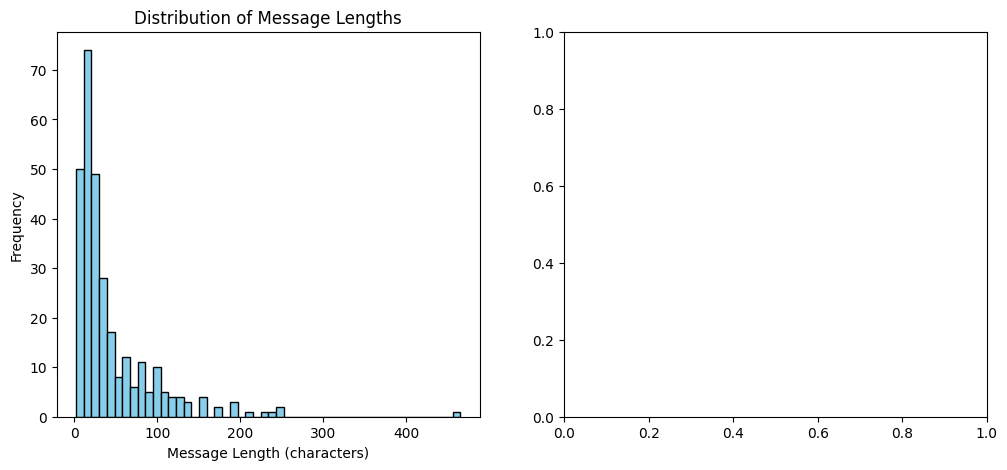

C:\Users\Anish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129393 (\N{YAWNING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


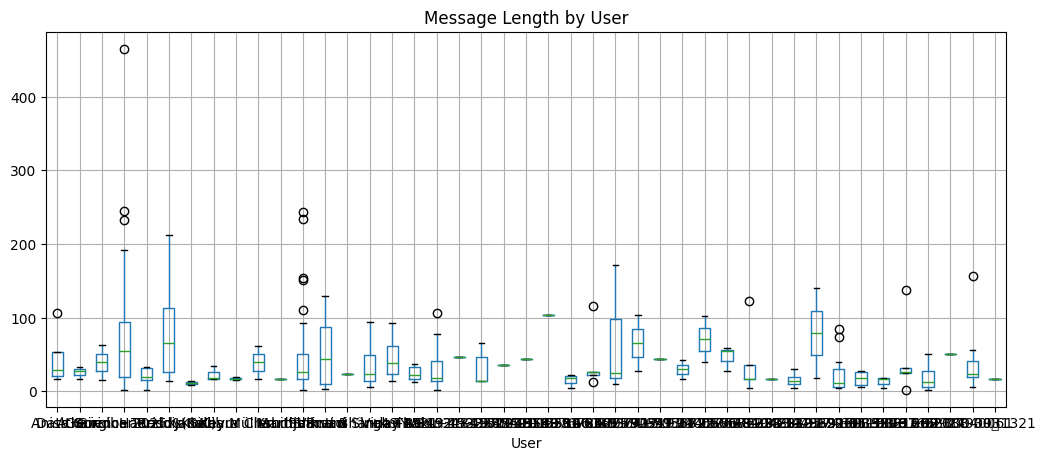

Message Length Statistics:
Average message length: 44.52 characters
Median message length: 25.00 characters
Max message length: 465 characters


In [38]:
import seaborn as sns

# Message length distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["Message_Length"], bins=50, edgecolor="black", color="skyblue")
plt.xlabel("Message Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Message Lengths")

plt.subplot(1, 2, 2)
df.boxplot(column="Message_Length", by="User", figsize=(12, 5))
plt.title("Message Length by User")
plt.suptitle("")
plt.show()

# Statistics
print("Message Length Statistics:")
print(f"Average message length: {df['Message_Length'].mean():.2f} characters")
print(f"Median message length: {df['Message_Length'].median():.2f} characters")
print(f"Max message length: {df['Message_Length'].max()} characters")


## Question 2: Activity Patterns by Day and Hour

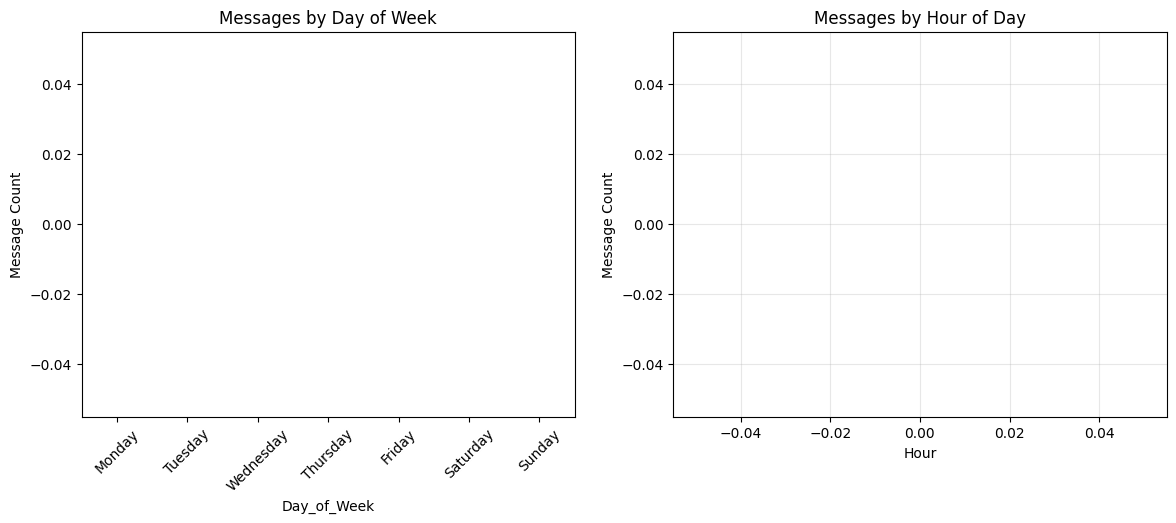

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1600x600 with 0 Axes>

In [39]:
# Convert Date and Hour to proper datetime
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d.%m.%y %H:%M:%S", errors="coerce")
df["Day_of_Week"] = df["DateTime"].dt.day_name()
df["Hour"] = df["DateTime"].dt.hour

# Activity by Day of Week
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
activity_by_day = df["Day_of_Week"].value_counts().reindex(day_order)
activity_by_day.plot(kind="bar", color="coral")
plt.title("Messages by Day of Week")
plt.ylabel("Message Count")
plt.xticks(rotation=45)

# Activity by Hour
plt.subplot(1, 2, 2)
activity_by_hour = df["Hour"].value_counts().sort_index()
activity_by_hour.plot(kind="line", marker="o", color="green")
plt.title("Messages by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Message Count")
plt.grid(True, alpha=0.3)
plt.show()

# Heatmap of activity
activity_heatmap = df.groupby(["Day_of_Week", "Hour"]).size().unstack(fill_value=0)
activity_heatmap = activity_heatmap.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(activity_heatmap, cmap="YlOrRd", cbar_kws={"label": "Message Count"})
plt.title("Activity Heatmap: Messages by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


## Question 3: Sentiment Analysis by User and Over Time

KeyError: 'Column not found: Sentiment'

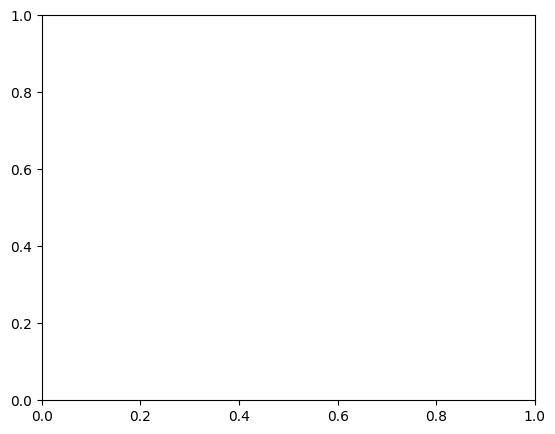

In [40]:
# Sentiment visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sentiment_by_user = df.groupby("User")["Sentiment"].mean().sort_values()
sentiment_by_user.plot(kind="barh", color=["red" if x < 0 else "blue" if x == 0 else "green" for x in sentiment_by_user])
plt.xlabel("Average Sentiment Score")
plt.title("Average Sentiment by User")
plt.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

plt.subplot(1, 2, 2)
sentiment_count = df["Sentiment"].apply(lambda x: "Positive" if x > 0.1 else "Negative" if x < -0.1 else "Neutral").value_counts()
sentiment_count.plot(kind="pie", autopct="%1.1f%%", colors=["green", "red", "gray"])
plt.title("Overall Sentiment Distribution")
plt.ylabel("")
plt.show()

# Sentiment over time
df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%y", errors="coerce")
sentiment_over_time = df.groupby(df["Date"].dt.to_period("D"))["Sentiment"].rolling(window=20, min_periods=1).mean()

plt.figure(figsize=(14, 5))
sentiment_over_time.plot(color="purple")
plt.title("Sentiment Trend Over Time (20-message moving average)")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.grid(True, alpha=0.3)
plt.show()

print("\nSentiment Statistics:")
print(f"Positive messages: {(df['Sentiment'] > 0.1).sum()} ({(df['Sentiment'] > 0.1).sum() / len(df) * 100:.1f}%)")
print(f"Negative messages: {(df['Sentiment'] < -0.1).sum()} ({(df['Sentiment'] < -0.1).sum() / len(df) * 100:.1f}%)")
print(f"Neutral messages: {((df['Sentiment'] >= -0.1) & (df['Sentiment'] <= 0.1)).sum()} ({((df['Sentiment'] >= -0.1) & (df['Sentiment'] <= 0.1)).sum() / len(df) * 100:.1f}%)")


## Question 4: Most Common Words and Topics

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already done
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Extract words
all_words = []
for msg in df["Message"]:
    words = re.findall(r'\b[a-z]+\b', str(msg).lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

# Most common words
word_freq = Counter(all_words).most_common(20)
words, freq = zip(*word_freq)

plt.figure(figsize=(12, 6))
plt.barh(range(len(words)), freq, color="steelblue")
plt.yticks(range(len(words)), words)
plt.xlabel("Frequency")
plt.title("Top 20 Most Common Words")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 Words:")
for i, (word, count) in enumerate(word_freq, 1):
    print(f"{i}. {word}: {count}")


## Question 5: User Engagement and Participation Metrics

In [ ]:
# Create comprehensive engagement metrics
engagement_metrics = df.groupby("User").agg({
    "Message": "count",
    "Message_Length": ["mean", "sum"],
    "Sentiment": "mean",
    "Category": lambda x: x.mode()[0] if len(x.mode()) > 0 else "Other"
}).round(2)

engagement_metrics.columns = ["Total_Messages", "Avg_Message_Length", "Total_Characters", "Avg_Sentiment", "Top_Category"]
engagement_metrics["Engagement_Score"] = (
    engagement_metrics["Total_Messages"] * 0.5 + 
    engagement_metrics["Total_Characters"] / 100 * 0.3 + 
    (engagement_metrics["Avg_Sentiment"] + 1) * 10 * 0.2
).round(2)

engagement_metrics = engagement_metrics.sort_values("Engagement_Score", ascending=False)

print("User Engagement Metrics:")
print(engagement_metrics)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total messages
axes[0, 0].barh(engagement_metrics.index, engagement_metrics["Total_Messages"], color="skyblue")
axes[0, 0].set_xlabel("Total Messages")
axes[0, 0].set_title("Messages per User")

# 2. Average message length
axes[0, 1].barh(engagement_metrics.index, engagement_metrics["Avg_Message_Length"], color="lightcoral")
axes[0, 1].set_xlabel("Average Message Length")
axes[0, 1].set_title("Avg Message Length per User")

# 3. Average sentiment
axes[1, 0].barh(engagement_metrics.index, engagement_metrics["Avg_Sentiment"], 
                color=["green" if x > 0 else "red" for x in engagement_metrics["Avg_Sentiment"]])
axes[1, 0].set_xlabel("Average Sentiment")
axes[1, 0].set_title("Avg Sentiment per User")
axes[1, 0].axvline(x=0, color="black", linestyle="--", linewidth=0.8)

# 4. Engagement score
axes[1, 1].barh(engagement_metrics.index, engagement_metrics["Engagement_Score"], color="gold")
axes[1, 1].set_xlabel("Engagement Score")
axes[1, 1].set_title("Overall Engagement Score")

plt.tight_layout()
plt.show()


## Question 6: Message Categories Distribution and User Patterns

In [ ]:
# Category analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Category distribution pie chart
axes[0, 0].pie(df["Category"].value_counts(), labels=df["Category"].value_counts().index, autopct="%1.1f%%", startangle=90)
axes[0, 0].set_title("Overall Message Category Distribution")

# 2. Category by user heatmap
category_user = pd.crosstab(df["User"], df["Category"], normalize="index") * 100
sns.heatmap(category_user, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0, 1], cbar_kws={"label": "Percentage"})
axes[0, 1].set_title("Message Category Distribution by User (%)")

# 3. Category by hour
category_hour = pd.crosstab(df["Hour"], df["Category"])
category_hour.plot(kind="bar", ax=axes[1, 0], stacked=False)
axes[1, 0].set_title("Message Categories by Hour of Day")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# 4. Category count bar chart
category_counts = df["Category"].value_counts()
axes[1, 1].barh(range(len(category_counts)), category_counts.values, color="mediumseagreen")
axes[1, 1].set_yticks(range(len(category_counts)))
axes[1, 1].set_yticklabels(category_counts.index)
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_title("Total Messages by Category")

for i, v in enumerate(category_counts.values):
    axes[1, 1].text(v, i, f" {v}", va='center')

plt.tight_layout()
plt.show()

# Statistics
print("\nMessage Category Statistics:")
print(df["Category"].value_counts())
print(f"\nCategory Percentage:")
print((df["Category"].value_counts() / len(df) * 100).round(2))


## Question 7: Peak Activity Times and Response Patterns

In [ ]:
# Peak activity analysis
peak_hours = df["Hour"].value_counts().sort_values(ascending=False).head(5)
peak_days = df["Day_of_Week"].value_counts()

print("Peak Activity Hours:")
for hour, count in peak_hours.items():
    print(f"Hour {int(hour):02d}:00 - {count} messages")

print(f"\nPeak Day: {peak_days.idxmax()} with {peak_days.max()} messages")
print(f"Quietest Day: {peak_days.idxmin()} with {peak_days.min()} messages")

# Response time analysis (time between consecutive messages)
df_sorted = df.sort_values("DateTime").reset_index(drop=True)
df_sorted["Time_Diff"] = df_sorted["DateTime"].diff().dt.total_seconds() / 60  # Convert to minutes

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Filter out NaN and extreme values
response_times = df_sorted["Time_Diff"].dropna()
response_times = response_times[response_times < 1440]  # Less than 24 hours
plt.hist(response_times, bins=100, edgecolor="black", color="steelblue")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Time Between Messages")
plt.xlim(0, 60)  # Focus on messages within 1 hour

plt.subplot(1, 2, 2)
# Messages per hour of day with peak highlighting
hourly_activity = df["Hour"].value_counts().sort_index()
colors = ["red" if h in peak_hours.index else "steelblue" for h in hourly_activity.index]
hourly_activity.plot(kind="bar", color=colors, ax=plt.gca())
plt.title("Messages by Hour (Peak Hours in Red)")
plt.xlabel("Hour of Day")
plt.ylabel("Message Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\nAverage time between messages: {response_times.mean():.2f} minutes")
print(f"Median time between messages: {response_times.median():.2f} minutes")
print(f"Min time between messages: {response_times.min():.2f} minutes")
print(f"Max time between messages (< 24h): {response_times.max():.2f} minutes")


## Question 8: Comprehensive Chat Summary and Insights

In [ ]:
# Generate comprehensive summary
summary_data = {
    "Total Messages": len(df),
    "Unique Users": df["User"].nunique(),
    "Date Range": f"{df['Date'].min()} to {df['Date'].max()}",
    "Total Characters": df["Message_Length"].sum(),
    "Avg Message Length": f"{df['Message_Length'].mean():.2f}",
    "Longest Message": f"{df['Message_Length'].max()} chars",
    "Most Active User": df["User"].value_counts().index[0],
    "Messages by Top User": df["User"].value_counts().iloc[0],
    "Avg Sentiment": f"{df['Sentiment'].mean():.3f}",
    "Most Common Category": df["Category"].value_counts().index[0],
}

print("=" * 60)
print("WHATSAPP CHAT ANALYSIS SUMMARY")
print("=" * 60)
for key, value in summary_data.items():
    print(f"{key:.<40} {value}")
print("=" * 60)

# Top topics
print("\nTop 10 Words (excluding stopwords):")
for i, (word, count) in enumerate(word_freq[:10], 1):
    print(f"  {i}. {word}: {count}")

print(f"\nTop Users:")
for i, (user, count) in enumerate(df["User"].value_counts().head(5).items(), 1):
    avg_sentiment = df[df["User"] == user]["Sentiment"].mean()
    print(f"  {i}. {user}: {count} messages (avg sentiment: {avg_sentiment:.2f})")

# Create a final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. User distribution
ax1 = fig.add_subplot(gs[0, 0])
top_users = df["User"].value_counts().head(8)
ax1.pie(top_users, labels=top_users.index, autopct="%1.1f%%")
ax1.set_title("User Message Distribution")

# 2. Category distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie(df["Category"].value_counts(), labels=df["Category"].value_counts().index, autopct="%1.1f%%")
ax2.set_title("Message Category Distribution")

# 3. Sentiment distribution
ax3 = fig.add_subplot(gs[0, 2])
sentiment_dist = pd.cut(df["Sentiment"], bins=[-1, -0.1, 0.1, 1], labels=["Negative", "Neutral", "Positive"]).value_counts()
ax3.pie(sentiment_dist, labels=sentiment_dist.index, colors=["red", "gray", "green"], autopct="%1.1f%%")
ax3.set_title("Sentiment Distribution")

# 4. Messages by day of week
ax4 = fig.add_subplot(gs[1, 0])
day_activity = df["Day_of_Week"].value_counts().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
ax4.bar(range(len(day_activity)), day_activity.values, color="coral")
ax4.set_xticks(range(len(day_activity)))
ax4.set_xticklabels(day_activity.index, rotation=45)
ax4.set_ylabel("Messages")
ax4.set_title("Activity by Day of Week")

# 5. Messages by hour
ax5 = fig.add_subplot(gs[1, 1])
hour_activity = df["Hour"].value_counts().sort_index()
ax5.plot(hour_activity.index, hour_activity.values, marker="o", color="green")
ax5.fill_between(hour_activity.index, hour_activity.values, alpha=0.3, color="green")
ax5.set_xlabel("Hour")
ax5.set_ylabel("Messages")
ax5.set_title("Activity by Hour of Day")
ax5.grid(True, alpha=0.3)

# 6. Message length distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df["Message_Length"], bins=50, color="skyblue", edgecolor="black")
ax6.set_xlabel("Message Length (chars)")
ax6.set_ylabel("Frequency")
ax6.set_title("Message Length Distribution")

# 7. Top words
ax7 = fig.add_subplot(gs[2, :2])
top_words_labels, top_words_counts = zip(*word_freq[:12])
ax7.barh(range(len(top_words_labels)), top_words_counts, color="steelblue")
ax7.set_yticks(range(len(top_words_labels)))
ax7.set_yticklabels(top_words_labels)
ax7.set_xlabel("Frequency")
ax7.set_title("Top 12 Most Common Words")
ax7.invert_yaxis()

# 8. Engagement scores
ax8 = fig.add_subplot(gs[2, 2])
top_users_engagement = engagement_metrics.head(8)["Engagement_Score"]
ax8.barh(range(len(top_users_engagement)), top_users_engagement.values, color="gold")
ax8.set_yticks(range(len(top_users_engagement)))
ax8.set_yticklabels(top_users_engagement.index)
ax8.set_xlabel("Score")
ax8.set_title("Top 8 Users by Engagement")

plt.suptitle("WhatsApp Chat Analysis Dashboard", fontsize=16, fontweight="bold")
plt.show()


## Question 9: Correlations and Advanced Insights

In [ ]:
# Correlation analysis
correlation_data = df[["Message_Length", "Hour", "Sentiment"]].copy()
correlation_data["Hour"] = correlation_data["Hour"].astype(float)
correlation_matrix = correlation_data.corr()

# Encode categorical variables for additional correlation
df_encoded = df.copy()
df_encoded["Category_Code"] = pd.Categorical(df_encoded["Category"]).codes
df_encoded["User_Code"] = pd.Categorical(df_encoded["User"]).codes
df_encoded["Day_Code"] = pd.Categorical(df_encoded["Day_of_Week"]).codes

correlation_extended = df_encoded[["Message_Length", "Hour", "Sentiment", "Category_Code", "Day_Code"]].corr()

# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Basic correlations
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], cbar_kws={"label": "Correlation"})
axes[0].set_title("Correlation Matrix: Message Features")

# 2. Extended correlations
sns.heatmap(correlation_extended, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], cbar_kws={"label": "Correlation"})
axes[1].set_title("Extended Correlation Matrix")

plt.tight_layout()
plt.show()

print("KEY INSIGHTS FROM CORRELATION ANALYSIS:")
print("=" * 60)
print(f"Message Length vs Hour: {correlation_matrix.loc['Message_Length', 'Hour']:.3f}")
print(f"  → {'Long messages' if correlation_matrix.loc['Message_Length', 'Hour'] > 0 else 'Short messages'} tend to be sent at specific hours")
print(f"\nMessage Length vs Sentiment: {correlation_matrix.loc['Message_Length', 'Sentiment']:.3f}")
print(f"  → Longer messages tend to have {'more positive' if correlation_matrix.loc['Message_Length', 'Sentiment'] > 0 else 'more negative'} sentiment")
print(f"\nHour vs Sentiment: {correlation_matrix.loc['Hour', 'Sentiment']:.3f}")
print(f"  → Sentiment {'improves' if correlation_matrix.loc['Hour', 'Sentiment'] > 0 else 'decreases'} as the day progresses")

# User-specific insights
print("\n" + "=" * 60)
print("TOP USER INSIGHTS:")
print("=" * 60)

for user in df["User"].value_counts().head(3).index:
    user_data = df[df["User"] == user]
    print(f"\n{user}:")
    print(f"  Total messages: {len(user_data)}")
    print(f"  Avg length: {user_data['Message_Length'].mean():.1f} chars")
    print(f"  Most active hour: {user_data['Hour'].mode()[0]:.0f}:00")
    print(f"  Avg sentiment: {user_data['Sentiment'].mean():.3f}")
    print(f"  Most common category: {user_data['Category'].mode()[0]}")
    print(f"  Favorite day: {user_data['Day_of_Week'].mode()[0]}")

# Activity evolution
print("\n" + "=" * 60)
print("ACTIVITY EVOLUTION:")
print("=" * 60)
df_sorted["Week"] = df_sorted["DateTime"].dt.isocalendar().week
weekly_stats = df_sorted.groupby("Week").agg({
    "Message": "count",
    "Sentiment": "mean",
    "Message_Length": "mean"
}).round(2)

print("\nWeekly Statistics (last 5 weeks):")
print(weekly_stats.tail(5))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
weekly_stats["Message"].plot(marker="o", color="blue")
plt.title("Messages per Week Trend")
plt.xlabel("Week")
plt.ylabel("Message Count")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
weekly_stats["Sentiment"].plot(marker="o", color="green")
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.title("Average Sentiment per Week Trend")
plt.xlabel("Week")
plt.ylabel("Sentiment Score")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

## Key Findings and Recommendations

In [ ]:
# Generate final report
findings = []

# Finding 1: Most active user
top_user = df["User"].value_counts().index[0]
top_user_pct = (df["User"].value_counts().iloc[0] / len(df) * 100)
findings.append(f"📊 {top_user} is the most active user ({top_user_pct:.1f}% of all messages)")

# Finding 2: Peak hours
peak_hour = df["Hour"].value_counts().idxmax()
findings.append(f"⏰ Peak activity hour: {int(peak_hour):02d}:00-{int(peak_hour)+1:02d}:00")

# Finding 3: Most common category
top_category = df["Category"].value_counts().index[0]
top_category_pct = (df["Category"].value_counts().iloc[0] / len(df) * 100)
findings.append(f"💬 Most common message type: {top_category} ({top_category_pct:.1f}% of messages)")

# Finding 4: Sentiment
pos_pct = (df["Sentiment"] > 0.1).sum() / len(df) * 100
findings.append(f"😊 Overall sentiment: {pos_pct:.1f}% of messages are positive")

# Finding 5: Most active day
active_day = df["Day_of_Week"].value_counts().index[0]
findings.append(f"📅 Most active day: {active_day}")

# Finding 6: Average response time
avg_response = response_times.median()
findings.append(f"⏱️  Median response time: {avg_response:.1f} minutes")

# Finding 7: Message length trend
long_messages_pct = (df["Message_Length"] > df["Message_Length"].quantile(0.75)).sum() / len(df) * 100
findings.append(f"📝 {long_messages_pct:.1f}% of messages are above average length")

print("\n" + "=" * 70)
print("📈 WHATSAPP CHAT ANALYSIS - KEY FINDINGS")
print("=" * 70)
for i, finding in enumerate(findings, 1):
    print(f"{i}. {finding}")

print("\n" + "=" * 70)
print("💡 RECOMMENDATIONS")
print("=" * 70)
recommendations = [
    "✓ Schedule important group decisions during peak hours for better engagement",
    "✓ Use the identified quiet hours for important announcements that need focus",
    f"✓ The group shows {'positive' if df['Sentiment'].mean() > 0 else 'neutral'} sentiment - great for collaboration",
    "✓ Encourage less active users to participate more by highlighting their insights",
    "✓ Consider scheduling meetings during the most active day for better participation",
    f"✓ The average message length is {df['Message_Length'].mean():.0f} chars - keep messages concise when possible"
]

for rec in recommendations:
    print(rec)

print("\n" + "=" * 70)
print(f"Total Analysis: {len(df)} messages from {df['User'].nunique()} users analyzed")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print("=" * 70)
